# Risk Prediction Model — Simple Version

Same overall flow as your original notebook, adapted to your dataset and trimmed down: **no exploratory boxplots, no model comparison chart.**

1. Load dataset
2. Check missing values & class balance
3. Prepare features (X) and target (y)
4. Train/test split 80/20
5. Train: Logistic Regression, Decision Tree, Random Forest, XGBoost
6. Compare results (simple table)
7. Confusion matrix + classification report for best model
8. Feature importance
9. Save trained model


## 0. Imports & Settings

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# XGBoost is optional. If it isn't installed, we just skip it later.
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed — that model will be skipped.")

RANDOM_STATE = 42
print("All imports OK.")


All imports OK.


## 1. Load Dataset

In [2]:
# The data file must be in the same folder as this notebook.
# HEADER_ROW = 3 because the first 3 rows of the Excel file are a title
# and a blank line, so the real column headers start on row 4.
DATASET_PATH = "Software_Project_Risk_Dataset_v2.xlsx"
HEADER_ROW = 3

df = pd.read_excel(DATASET_PATH, header=HEADER_ROW)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (1500, 15)
Columns: ['Project_ID', 'KSLOC', 'CPLX', 'Effort_PM', 'Duration_Months', 'Capability_Index', 'Requirements_Change_Count', 'Schedule_Pressure_Index', 'Team_Size', 'Defect_Count', 'Defect_Density', 'Defect_Resolution_Rate', 'Defect_Trend', 'Risk_Level', 'Risk_Label']


,Project_ID,KSLOC,CPLX,Effort_PM,Duration_Months,Capability_Index,Requirements_Change_Count,Schedule_Pressure_Index,Team_Size,Defect_Count,Defect_Density,Defect_Resolution_Rate,Defect_Trend,Risk_Level,Risk_Label
0,1,78.4,4,297.1,7.23,3,5,2.50,10,974,12.42,77.1,1,3,High
1,2,108.2,2,417.9,7.95,2,5,2.50,6,478,4.42,68.6,1,2,Medium
2,3,68.3,4,256.2,11.96,3,3,1.45,10,742,10.86,90.5,1,1,Low
3,4,60.7,3,179.6,13.77,3,10,1.14,4,316,5.21,88.4,1,2,Medium
4,5,118.0,3,495.2,21.95,2,2,0.95,9,945,8.01,48.8,3,1,Low


## 2. Check Missing Values & Class Balance

In [3]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nClass balance (Risk_Label):")
print(df["Risk_Label"].value_counts())


Missing values per column:
Project_ID                   0
KSLOC                        0
CPLX                         0
Effort_PM                    0
Duration_Months              0
Capability_Index             0
Requirements_Change_Count    0
Schedule_Pressure_Index      0
Team_Size                    0
Defect_Count                 0
Defect_Density               0
Defect_Resolution_Rate       0
Defect_Trend                 0
Risk_Level                   0
Risk_Label                   0
dtype: int64

Class balance (Risk_Label):
Risk_Label
Low       501
High      500
Medium    499
Name: count, dtype: int64


## 3. Prepare Features (X) and Target (y)
`Risk_Label` is text, so we encode it into numbers using `LabelEncoder`.

In [4]:
# These are the measurable project attributes used as input features.
# Project_ID is just an ID number, and Risk_Level is a numeric copy of
# Risk_Label itself, so both are left out to avoid giving the answer away.
FEATURE_COLS = [
    "KSLOC",
    "CPLX",
    "Effort_PM",
    "Duration_Months",
    "Capability_Index",
    "Requirements_Change_Count",
    "Schedule_Pressure_Index",
    "Team_Size",
    "Defect_Count",
    "Defect_Density",
    "Defect_Resolution_Rate",
    "Defect_Trend",
]

X = df[FEATURE_COLS]

# LabelEncoder converts "Low"/"Medium"/"High" into 0/1/2
le = LabelEncoder()
y = le.fit_transform(df["Risk_Label"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", list(le.classes_))


X shape: (1500, 12)
y shape: (1500,)
Classes: ['High', 'Low', 'Medium']


## 4. Train/Test Split (80/20)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

# Logistic Regression needs scaled features. Tree-based models do not.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training set size: 1200
Testing set size: 300


## 5. Train Models

In [6]:
# Dictionary to store each trained model
models = {}

# Dictionary to store predictions from each model
predictions = {}

# ---- Logistic Regression ----
log_reg_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg_model.fit(X_train_scaled, y_train)
models["Logistic Regression"] = log_reg_model
predictions["Logistic Regression"] = log_reg_model.predict(X_test_scaled)

# ---- Decision Tree ----
tree_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)
models["Decision Tree"] = tree_model
predictions["Decision Tree"] = tree_model.predict(X_test)

# ---- Random Forest ----
forest_model = RandomForestClassifier(random_state=RANDOM_STATE)
forest_model.fit(X_train, y_train)
models["Random Forest"] = forest_model
predictions["Random Forest"] = forest_model.predict(X_test)

# ---- XGBoost (only if installed) ----
if HAS_XGB:
    xgb_model = XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss")
    xgb_model.fit(X_train, y_train)
    models["XGBoost"] = xgb_model
    predictions["XGBoost"] = xgb_model.predict(X_test)
else:
    print("Skipping XGBoost (not installed).")

print("Models trained:", list(models.keys()))


Models trained: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


## 6. Compare Results
A simple printed table — no chart.

In [7]:
rows = []
for name in models:
    preds = predictions[name]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average="weighted"),
        "Recall": recall_score(y_test, preds, average="weighted"),
        "F1-score": f1_score(y_test, preds, average="weighted"),
    })

results_df = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
print(results_df)

# The best model is the one with the highest F1-score
best_name = results_df.loc[0, "Model"]
best_model = models[best_name]
best_predictions = predictions[best_name]

print("\nBest model:", best_name)


                 Model  Accuracy  Precision    Recall  F1-score
0              XGBoost  0.900000   0.899194  0.900000  0.899193
1  Logistic Regression  0.880000   0.881127  0.880000  0.880380
2        Random Forest  0.816667   0.813870  0.816667  0.812613
3        Decision Tree  0.800000   0.800263  0.800000  0.800090

Best model: XGBoost


## 7. Confusion Matrix + Classification Report (Best Model)

Best model: XGBoost


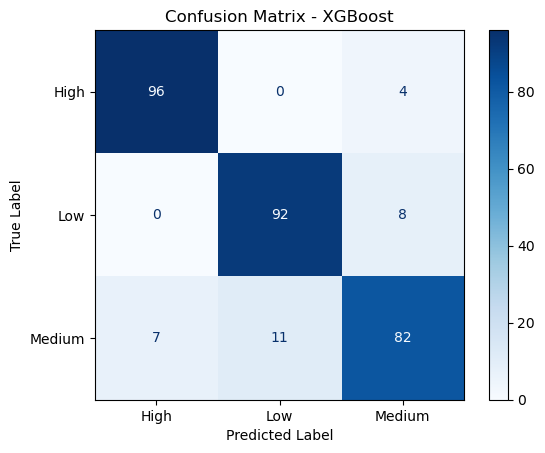

In [13]:
print("Best model:", best_name)

conf_matrix = confusion_matrix(y_test, best_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=le.classes_
)

display.plot(cmap="Blues")

plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## 8. Feature Importance (Best Model)

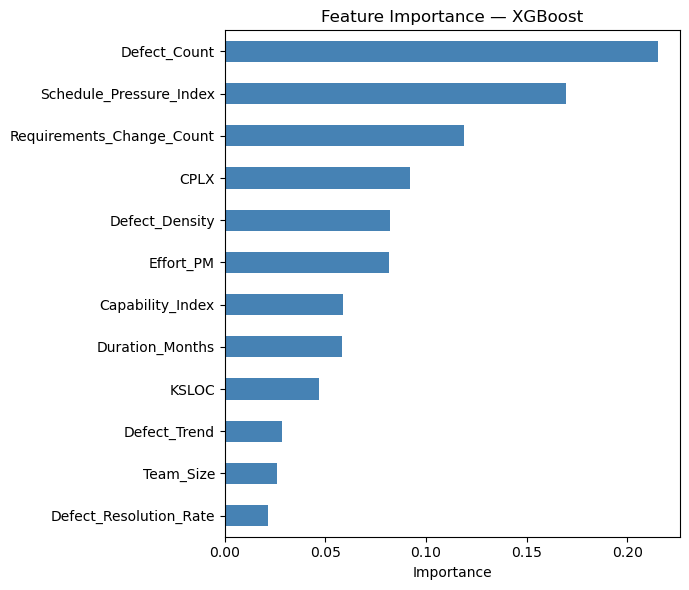

In [14]:
tree_based = ("Decision Tree", "Random Forest", "XGBoost")

if best_name in tree_based:
    importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=True)

    plt.figure(figsize=(7, 6))
    importances.plot(kind="barh", color="steelblue")
    plt.title(f"Feature Importance — {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("feature_importance.png")
    plt.show()
else:
    # Logistic Regression: use the size of each coefficient instead
    coef_abs = np.abs(best_model.coef_).mean(axis=0)
    importances = pd.Series(coef_abs, index=FEATURE_COLS).sort_values(ascending=True)

    plt.figure(figsize=(7, 6))
    importances.plot(kind="barh", color="steelblue")
    plt.title(f"Feature Importance (|coefficient|) — {best_name}")
    plt.xlabel("Mean |Coefficient|")
    plt.tight_layout()
    plt.savefig("feature_importance.png")
    plt.show()


## 9. Save Trained Model

In [15]:
import joblib

joblib.dump(best_model, "risk_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Saved:")
print("  risk_model.pkl     — best trained model")
print("  scaler.pkl         — StandardScaler (needed if best model is Logistic Regression)")
print("  label_encoder.pkl  — maps 0/1/2 <-> Low/Medium/High")

print(f"\nModel type : {type(best_model).__name__}")
print(f"Features   : {len(FEATURE_COLS)}")
print(f"Classes    : {list(le.classes_)}")
print(f"Best F1    : {results_df.iloc[0]['F1-score']:.4f}")


Saved:
  risk_model.pkl     — best trained model
  scaler.pkl         — StandardScaler (needed if best model is Logistic Regression)
  label_encoder.pkl  — maps 0/1/2 <-> Low/Medium/High

Model type : XGBClassifier
Features   : 12
Classes    : ['High', 'Low', 'Medium']
Best F1    : 0.8992
